# TB Treatment Outcome Prediction — Baseline Model Benchmarking

**Dataset:** TB Case Notifications, Cordillera Administrative Region (CAR), Philippines (2015–2025)  
**Task:** Binary classification — predict **Treatment Success** vs **Treatment Failure**  
**Approach:** Benchmark 12 ML models using demographic and clinical features

### Target Definition
| Label | Outcome/Status values |
|---|---|
| **Success (1)** | TREATMENT COMPLETED, CURED |
| **Failure (0)** | DIED, LOST TO FF-UP, FAILED |

> Records with ambiguous status (ON TREATMENT, EXCLUDED, DIAGNOSED, NOT EVALUATED, NOT ENROLLED, Screened) are excluded.

## 1. Setup and Imports

In [21]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
from pathlib import Path

# Sklearn — preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Sklearn — models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB

# Sklearn — metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

# Gradient boosting libraries
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Utilities
import time
import joblib

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Output directories
img_dir = Path('baseline_outputs/images')
model_dir = Path('baseline_outputs/models')
img_dir.mkdir(parents=True, exist_ok=True)
model_dir.mkdir(parents=True, exist_ok=True)

print('All libraries imported successfully.')

All libraries imported successfully.


## 2. Data Loading and Target Engineering

In [22]:
# Load the ML-ready dataset (features already label-encoded + standard-scaled)
df_raw = pd.read_csv('../dataset/non-temporal/2015-2025-ml-ready.csv')
print(f'ML-ready dataset shape: {df_raw.shape}')
print(f'Columns: {list(df_raw.columns)}')
print(f'\nNumeric columns: {df_raw.select_dtypes(include="number").columns.tolist()}')
print(f'Object columns : {df_raw.select_dtypes(include="object").columns.tolist()}')

# ── Decode Outcome/Status back to original labels ─────────────────────────
# The ml-ready CSV used LabelEncoder (alphabetical → 0..10) then StandardScaler.
# Sorting the unique encoded floats restores alphabetical order of original labels.
OUTCOME_LABELS_ALPHA = [
    'CURED', 'DIAGNOSED', 'DIED', 'EXCLUDED', 'FAILED', 'LOST TO FF-UP',
    'NOT ENROLLED', 'NOT EVALUATED', 'ON TREATMENT', 'Screened', 'TREATMENT COMPLETED'
]
outcome_encoded_sorted = sorted(df_raw['Outcome/Status'].dropna().unique())
OUTCOME_DECODE = dict(zip(outcome_encoded_sorted, OUTCOME_LABELS_ALPHA))

df_raw['Outcome_Label'] = df_raw['Outcome/Status'].map(OUTCOME_DECODE)
print(f'\nOutcome decoding (encoded → label):')
for enc, lbl in OUTCOME_DECODE.items():
    print(f'  {enc:+.6f} → {lbl}')

ML-ready dataset shape: (7389, 28)
Columns: ['Type', 'Validation Status', 'Date of Screening', 'Date of Diagnosis', 'Date of Notification', 'Birthdate', 'Age', 'Sex', 'Brgy', 'City/Municipality', 'Province', 'Region', 'Screening/Diagnosing Health Facility', 'Treatment Health Facility', 'Source of Patient', 'Anatomical Site', 'Registration Group', 'Bacteriologic Status', 'Microscopy Result', 'Microscopy Release Date', 'RDT Result', 'RDT Release Date', 'Date Started Tx', 'Outcome/Status', 'Date of Outcome/Status', 'Year', 'Days_To_Treatment', 'Computed_Age']

Numeric columns: ['Type', 'Validation Status', 'Date of Screening', 'Date of Notification', 'Age', 'Sex', 'Brgy', 'City/Municipality', 'Province', 'Region', 'Screening/Diagnosing Health Facility', 'Treatment Health Facility', 'Source of Patient', 'Anatomical Site', 'Registration Group', 'Bacteriologic Status', 'Microscopy Result', 'Microscopy Release Date', 'RDT Result', 'RDT Release Date', 'Outcome/Status', 'Date of Outcome/Status'

Usable records after removing ambiguous outcomes: 6,797
Excluded (ambiguous): 592

Target distribution:
  Success (1): 5,858 (86.2%)
  Failure (0): 939 (13.8%)


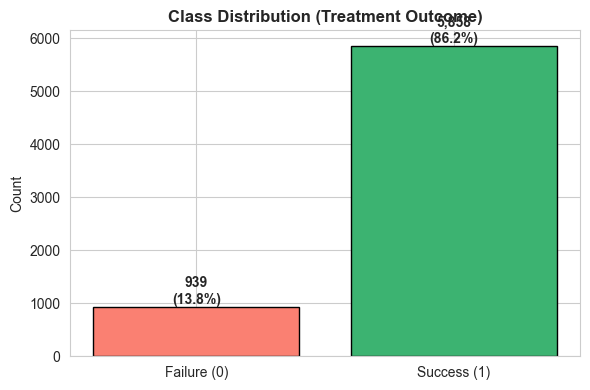

In [23]:
# Define target variable (using decoded labels)
SUCCESS_OUTCOMES = {'TREATMENT COMPLETED', 'CURED'}
FAILURE_OUTCOMES  = {'DIED', 'LOST TO FF-UP', 'FAILED'}

df = df_raw[df_raw['Outcome_Label'].isin(SUCCESS_OUTCOMES | FAILURE_OUTCOMES)].copy()
df['Target'] = df['Outcome_Label'].apply(lambda x: 1 if x in SUCCESS_OUTCOMES else 0)

print(f'Usable records after removing ambiguous outcomes: {len(df):,}')
print(f"Excluded (ambiguous): {len(df_raw) - len(df):,}")
print()

class_counts = df['Target'].value_counts()
print('Target distribution:')
print(f"  Success (1): {class_counts[1]:,} ({class_counts[1]/len(df)*100:.1f}%)")
print(f"  Failure (0): {class_counts[0]:,} ({class_counts[0]/len(df)*100:.1f}%)")

# Visualise class balance
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Failure (0)', 'Success (1)'], class_counts[[0, 1]].values,
              color=['salmon', 'mediumseagreen'], edgecolor='black')
for bar, val in zip(bars, class_counts[[0, 1]].values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('Count')
ax.set_title('Class Distribution (Treatment Outcome)', fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_outputs/images/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Feature Engineering

In [24]:
# ── Feature selection ────────────────────────────────────────────────────────
# In the ML-ready dataset, all features are already label-encoded and standard-scaled.
# We select features directly as numeric columns — no OneHot / Ordinal encoding needed.

ALL_FEATURES = [
    'Age',
    'Days_To_Treatment',
    'Year',
    'Sex',
    'Anatomical Site',
    'Registration Group',
    'Bacteriologic Status',
    'Microscopy Result',
    'Source of Patient',
    'Type',
    'Province',
]

X = df[ALL_FEATURES].copy()
y = df['Target'].values

# Fill Age from Computed_Age where still NaN (both are already scaled)
X['Age'] = X['Age'].fillna(df['Computed_Age'])

print(f'Feature matrix shape: {X.shape}')
print(f'All features are pre-encoded & scaled (from ml-ready.csv)')
print(f'\nMissing values per feature:')
print(X.isnull().sum())

Feature matrix shape: (6797, 11)
All features are pre-encoded & scaled (from ml-ready.csv)

Missing values per feature:
Age                     0
Days_To_Treatment       0
Year                    0
Sex                     0
Anatomical Site         0
Registration Group      0
Bacteriologic Status    0
Microscopy Result       0
Source of Patient       0
Type                    0
Province                0
dtype: int64


## 4. Preprocessing Pipeline

In [25]:
# ── Build sklearn preprocessing pipeline ───────────────────────────────────
# Data is already label-encoded + standard-scaled from ml-ready.csv.
# Only need to impute any remaining NaN values (median preserves scaled distribution).
preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
])

# ── Train / test split ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'Train size: {len(X_train):,}  |  Test size: {len(X_test):,}')
print(f'Train class balance — Success: {y_train.sum():,} / Failure: {(y_train==0).sum():,}')
print(f'Test  class balance — Success: {y_test.sum():,} / Failure: {(y_test==0).sum():,}')

Train size: 5,437  |  Test size: 1,360
Train class balance — Success: 4,686 / Failure: 751
Test  class balance — Success: 1,172 / Failure: 188


## 5. Model Definitions

In [26]:
# ── Define model zoo ───────────────────────────────────────────────────────
MODELS = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'
    ),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=7),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=8, random_state=RANDOM_STATE, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=12, random_state=RANDOM_STATE,
        class_weight='balanced', n_jobs=-1
    ),
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=200, max_depth=12, random_state=RANDOM_STATE,
        class_weight='balanced', n_jobs=-1
    ),
    'AdaBoost': AdaBoostClassifier(
        n_estimators=100, random_state=RANDOM_STATE
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        random_state=RANDOM_STATE, subsample=0.8
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        random_state=RANDOM_STATE, eval_metric='logloss',
        scale_pos_weight=(y_train == 0).sum() / y_train.sum(),
        n_jobs=-1, verbosity=0
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        random_state=RANDOM_STATE, class_weight='balanced',
        n_jobs=-1, verbose=-1
    ),
    'MLP Neural Network': MLPClassifier(
        hidden_layer_sizes=(128, 64, 32), activation='relu',
        max_iter=500, random_state=RANDOM_STATE, early_stopping=True,
        validation_fraction=0.1, learning_rate_init=0.001
    ),
    'SVM (RBF)': SVC(
        kernel='rbf', probability=True, random_state=RANDOM_STATE,
        class_weight='balanced', C=1.0, gamma='scale'
    ),
}

print(f'{len(MODELS)} models defined:')
for name in MODELS:
    print(f'  • {name}')

12 models defined:
  • Logistic Regression
  • Naive Bayes
  • K-Nearest Neighbors
  • Decision Tree
  • Random Forest
  • Extra Trees
  • AdaBoost
  • Gradient Boosting
  • XGBoost
  • LightGBM
  • MLP Neural Network
  • SVM (RBF)


## 6. Training and Benchmarking

In [27]:

# ── Helper: extract iteration / epoch count from a fitted estimator ────────
def get_iterations(clf):
    """
    Return the number of iterations (epochs) or trees for a fitted model.
      • Iterative  (LR, MLP, SVM) : n_iter_ until convergence / early-stop
      • Ensemble   (RF, ET, GB)   : n_estimators (trees / boosting stages)
      • Boosting   (XGB, LGB)     : n_estimators (configured stages)
      • AdaBoost                  : n_estimators_ (actual estimators used)
      • Non-iterative (KNN, NB, DT): '—'
    """
    if hasattr(clf, 'n_iter_'):
        ni = clf.n_iter_
        if hasattr(ni, '__len__'):
            return int(max(ni))   # MLP → max epochs; SVM → max across classes
        return int(ni)            # LR  → scalar iterations to convergence
    if hasattr(clf, 'n_estimators_'):
        return int(clf.n_estimators_)   # AdaBoost: actual estimators used
    if hasattr(clf, 'n_estimators'):
        return int(clf.n_estimators)    # RF, ET, GB, XGB, LGB
    return '—'                          # KNN, Naive Bayes, DT


# ── Train all models, collect metrics ─────────────────────────────────────
results = []
trained_pipelines = {}

for name, model in MODELS.items():
    print(f'Training {name}...', end='  ', flush=True)
    t0 = time.time()

    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    pipe.fit(X_train, y_train)

    train_time = time.time() - t0
    clf = pipe.named_steps['classifier']

    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    results.append({
        'Model':              name,
        'Accuracy':           accuracy_score(y_test, y_pred),
        'Precision':          precision_score(y_test, y_pred, zero_division=0),
        'Recall':             recall_score(y_test, y_pred, zero_division=0),
        'F1-Score':           f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC':            roc_auc_score(y_test, y_proba),
        'Train Time (s)':     round(train_time, 2),
        'Iterations / Trees': get_iterations(clf),
    })
    trained_pipelines[name] = pipe
    print(f'done ({train_time:.1f}s,  iters/trees={get_iterations(clf)})')

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results_df.index += 1

# Format for display
display_df = results_df.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']:
    display_df[col] = display_df[col].map('{:.4f}'.format)

print('\n' + '='*105)
print('MODEL BENCHMARKING RESULTS (sorted by ROC-AUC)')
print('  Iterations/Trees: convergence iters (LR/MLP/SVM) | n_estimators (ensemble) | — (non-iterative)')
print('='*105)
print(display_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score',
                   'ROC-AUC', 'Train Time (s)', 'Iterations / Trees']].to_string())


Training Logistic Regression...  done (0.0s,  iters/trees=7)
Training Naive Bayes...  done (0.0s,  iters/trees=—)
Training K-Nearest Neighbors...  done (0.0s,  iters/trees=—)
Training Decision Tree...  done (0.0s,  iters/trees=—)
Training Random Forest...  done (0.2s,  iters/trees=200)
Training Extra Trees...  done (0.5s,  iters/trees=200)
Training AdaBoost...  done (0.5s,  iters/trees=100)
Training Gradient Boosting...  done (1.1s,  iters/trees=200)
Training XGBoost...  done (0.3s,  iters/trees=200)
Training LightGBM...  done (0.6s,  iters/trees=200)
Training MLP Neural Network...  done (0.2s,  iters/trees=13)
Training SVM (RBF)...  done (2.6s,  iters/trees=6467)

MODEL BENCHMARKING RESULTS (sorted by ROC-AUC)
  Iterations/Trees: convergence iters (LR/MLP/SVM) | n_estimators (ensemble) | — (non-iterative)
                  Model Accuracy Precision  Recall F1-Score ROC-AUC  Train Time (s) Iterations / Trees
1             SVM (RBF)   0.6434    0.9124  0.6485   0.7581  0.6961            

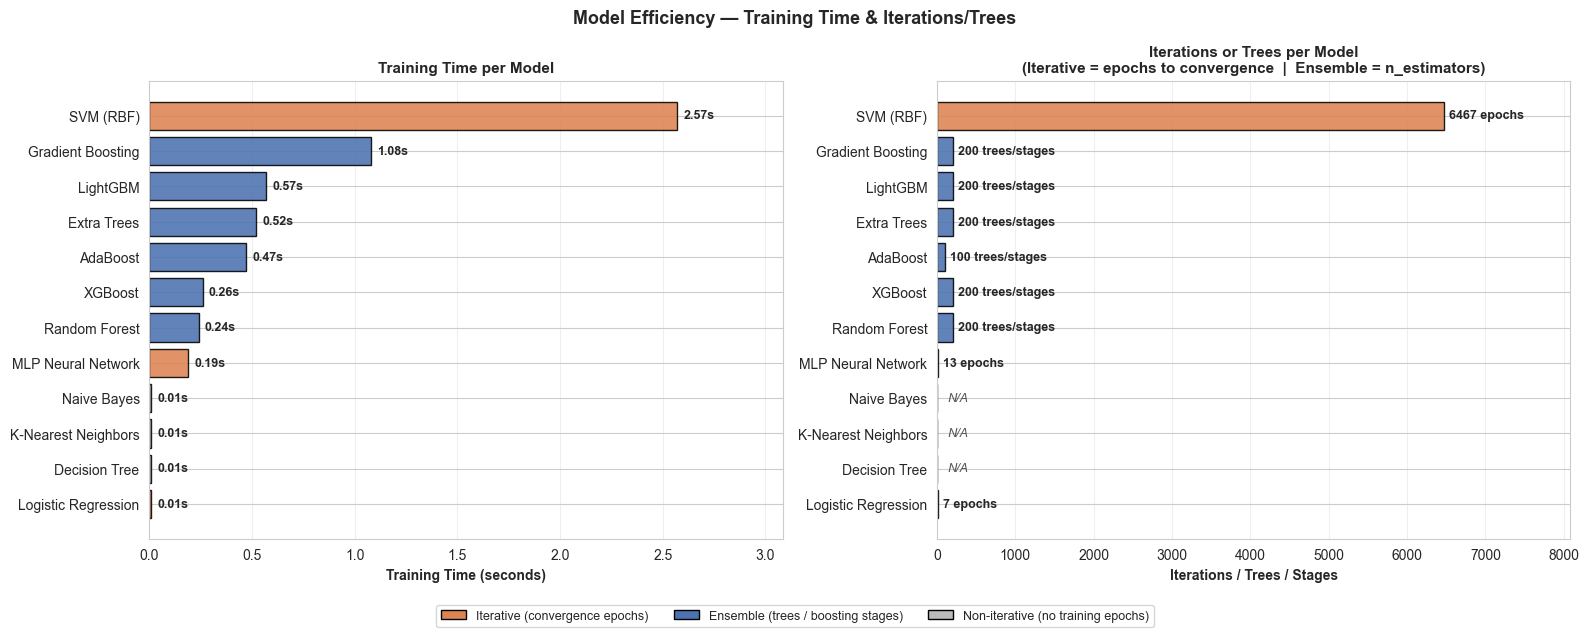

Saved: training_time_iterations.png


In [41]:

# ── Training Time & Iterations / Epochs visualisation ─────────────────────
# Model category colours:
#   Orange  → iterative  (convergence-based: LR, MLP, SVM)
#   Steel   → ensemble   (tree-based:  RF, ET, GB, XGB, LGB, AdaBoost)
#   Silver  → non-iter.  (no epochs:   KNN, Naive Bayes, Decision Tree)

ITERATIVE  = {'Logistic Regression', 'MLP Neural Network', 'SVM (RBF)'}
ENSEMBLE   = {'Random Forest', 'Extra Trees', 'Gradient Boosting',
              'XGBoost', 'LightGBM', 'AdaBoost'}

CAT_COLOR  = {'iterative': '#DD8452', 'ensemble': '#4C72B0', 'non-iter': '#BBBBBB'}
CAT_LABEL  = {
    'iterative': 'Iterative (convergence epochs)',
    'ensemble':  'Ensemble (trees / boosting stages)',
    'non-iter':  'Non-iterative (no training epochs)',
}

def model_category(name):
    if name in ITERATIVE: return 'iterative'
    if name in ENSEMBLE:  return 'ensemble'
    return 'non-iter'

# Build sorted plotting frame (sorted by training time ascending)
plot_data = (
    results_df[['Model', 'Train Time (s)', 'Iterations / Trees']]
    .copy()
    .sort_values('Train Time (s)', ascending=True)
    .reset_index(drop=True)
)
plot_data['Category']   = plot_data['Model'].apply(model_category)
plot_data['Color']      = plot_data['Category'].map(CAT_COLOR)
plot_data['IterHeight'] = plot_data['Iterations / Trees'].apply(
    lambda v: 0 if v == '—' else int(v))
plot_data['IterUnit']   = plot_data.apply(
    lambda r: 'N/A' if r['Iterations / Trees'] == '—'
    else ('epochs' if r['Category'] == 'iterative' else 'trees/stages'), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: Training Time ────────────────────────────────────────────────────
bars_t = axes[0].barh(
    plot_data['Model'], plot_data['Train Time (s)'],
    color=plot_data['Color'], edgecolor='black', alpha=0.88
)
for bar, val in zip(bars_t, plot_data['Train Time (s)']):
    axes[0].text(val + 0.03, bar.get_y() + bar.get_height() / 2,
                 f'{val:.2f}s', va='center', fontsize=9, fontweight='bold')
axes[0].set_xlabel('Training Time (seconds)', fontweight='bold')
axes[0].set_title('Training Time per Model', fontweight='bold', fontsize=11)
axes[0].grid(axis='x', alpha=0.3)
axes[0].set_xlim(0, plot_data['Train Time (s)'].max() * 1.2)

# ── Right: Iterations / Epochs / Trees ────────────────────────────────────
max_iter = plot_data['IterHeight'].max()
bars_i = axes[1].barh(
    plot_data['Model'], plot_data['IterHeight'],
    color=plot_data['Color'], edgecolor='black', alpha=0.88
)
for bar, val, unit in zip(bars_i, plot_data['IterHeight'], plot_data['IterUnit']):
    if unit == 'N/A':
        axes[1].text(max_iter * 0.02, bar.get_y() + bar.get_height() / 2,
                     'N/A', va='center', fontsize=9,
                     color='#555555', fontstyle='italic')
    else:
        axes[1].text(val + max_iter * 0.01, bar.get_y() + bar.get_height() / 2,
                     f'{val} {unit}', va='center', fontsize=9, fontweight='bold')

axes[1].set_xlabel('Iterations / Trees / Stages', fontweight='bold')
axes[1].set_title('Iterations or Trees per Model\n'
                  '(Iterative = epochs to convergence  |  Ensemble = n_estimators)',
                  fontweight='bold', fontsize=11)
axes[1].grid(axis='x', alpha=0.3)
axes[1].set_xlim(0, max_iter * 1.25)

# ── Shared legend ──────────────────────────────────────────────────────────
from matplotlib.patches import Patch
legend_patches = [Patch(facecolor=CAT_COLOR[k], label=CAT_LABEL[k], edgecolor='black')
                  for k in CAT_COLOR]
fig.legend(handles=legend_patches, loc='lower center', ncol=3,
           fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.06))

plt.suptitle('Model Efficiency — Training Time & Iterations/Trees', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_outputs/images/training_time_iterations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_time_iterations.png')


### 6a. Learning Curves — All Models

How training and validation ROC-AUC change as training data grows.  
*Gap between train and val = overfitting; both lines low = underfitting.*


Learning curve: Logistic Regression...
Learning curve: Naive Bayes...
Learning curve: K-Nearest Neighbors...
Learning curve: Decision Tree...
Learning curve: Random Forest...
Learning curve: Extra Trees...
Learning curve: AdaBoost...
Learning curve: Gradient Boosting...
Learning curve: XGBoost...
Learning curve: LightGBM...
Learning curve: MLP Neural Network...
Learning curve: SVM (RBF)...


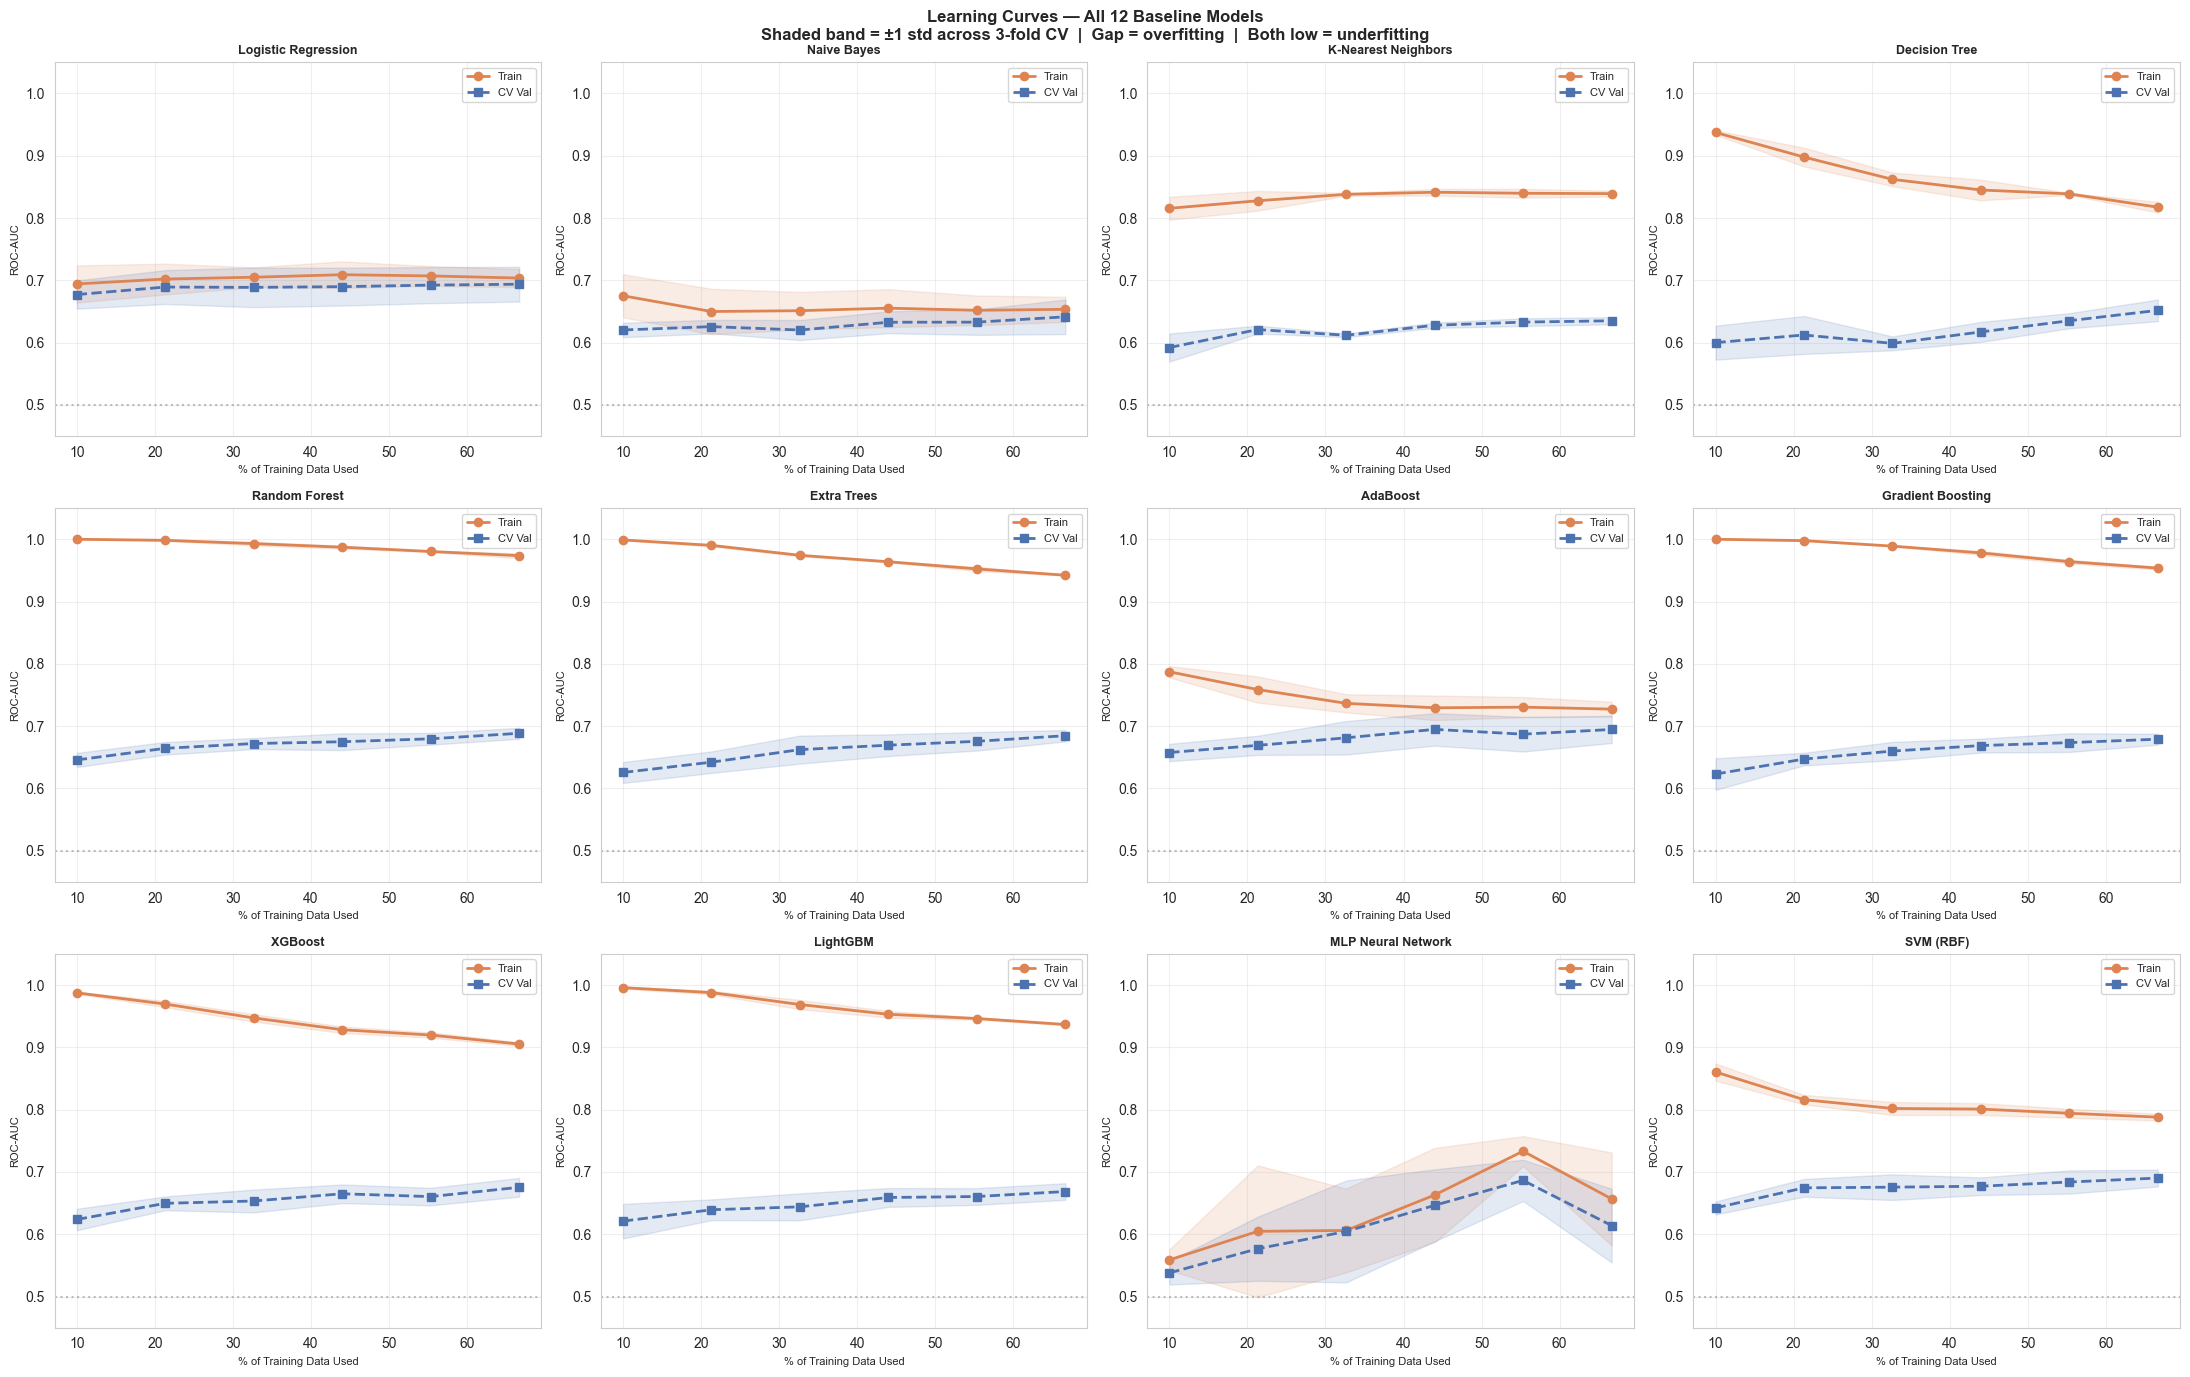


Saved: learning_curves_baseline.png


In [42]:

from sklearn.model_selection import learning_curve as sk_learning_curve
from sklearn.base import clone

# ── Learning curves for all 12 baseline models ─────────────────────────────
# 3-fold CV, ROC-AUC, 6 training sizes (15% → 100% of X_train)
# NOTE: SVM may take ~1–2 min at full training size.

fig, axes = plt.subplots(3, 4, figsize=(22, 14))
axes = axes.flatten()

train_sizes_frac = np.linspace(0.15, 1.0, 6)

for ax, (name, pipe) in zip(axes, trained_pipelines.items()):
    print(f'Learning curve: {name}...', flush=True)
    train_sizes, train_scores, val_scores = sk_learning_curve(
        clone(pipe), X_train, y_train,
        train_sizes=train_sizes_frac,
        cv=3, scoring='roc_auc',
        n_jobs=-1, shuffle=True, random_state=RANDOM_STATE
    )
    sizes_pct  = train_sizes / len(X_train) * 100
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(sizes_pct, train_mean, 'o-',  color='#DD8452', label='Train',  linewidth=2)
    ax.fill_between(sizes_pct, train_mean - train_std, train_mean + train_std,
                    alpha=0.15, color='#DD8452')
    ax.plot(sizes_pct, val_mean,   's--', color='#4C72B0', label='CV Val', linewidth=2)
    ax.fill_between(sizes_pct, val_mean - val_std, val_mean + val_std,
                    alpha=0.15, color='#4C72B0')

    ax.set_title(name, fontweight='bold', fontsize=9)
    ax.set_xlabel('% of Training Data Used', fontsize=8)
    ax.set_ylabel('ROC-AUC', fontsize=8)
    ax.set_ylim(0.45, 1.05)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)

plt.suptitle(
    'Learning Curves — All 12 Baseline Models\n'
    'Shaded band = ±1 std across 3-fold CV  |  Gap = overfitting  |  Both low = underfitting',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('baseline_outputs/images/learning_curves_baseline.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved: learning_curves_baseline.png')



### 6b. Per-Stage / Epoch Curves — Model-Specific

| Model | Approach |
|---|---|
| **Logistic Regression** | `max_iter` loop → ROC-AUC per epoch (log-scale x-axis) |
| **MLP Neural Network** | `loss_curve_` (train) + `validation_scores_` (val accuracy) from fitted model |
| **SVM (RBF)** | Retrain across C values → ROC-AUC vs regularization strength |
| **Random Forest / Extra Trees** | Retrain with increasing `n_estimators` → tree-count saturation |
| **AdaBoost / Gradient Boosting** | `staged_predict_proba` → ROC-AUC per boosting stage |
| **XGBoost / LightGBM** | Retrain with `eval_set` → log-loss per stage tracked natively |

*KNN, Naive Bayes, and Decision Tree are non-iterative — no stage/epoch curves applicable.*


LR epoch curve...
MLP epoch curve...
SVM C-sweep curve...
Random Forest tree-count curve...
Extra Trees tree-count curve...
AdaBoost staged curve...
GB staged curve...
XGBoost staged curve...
LightGBM staged curve...


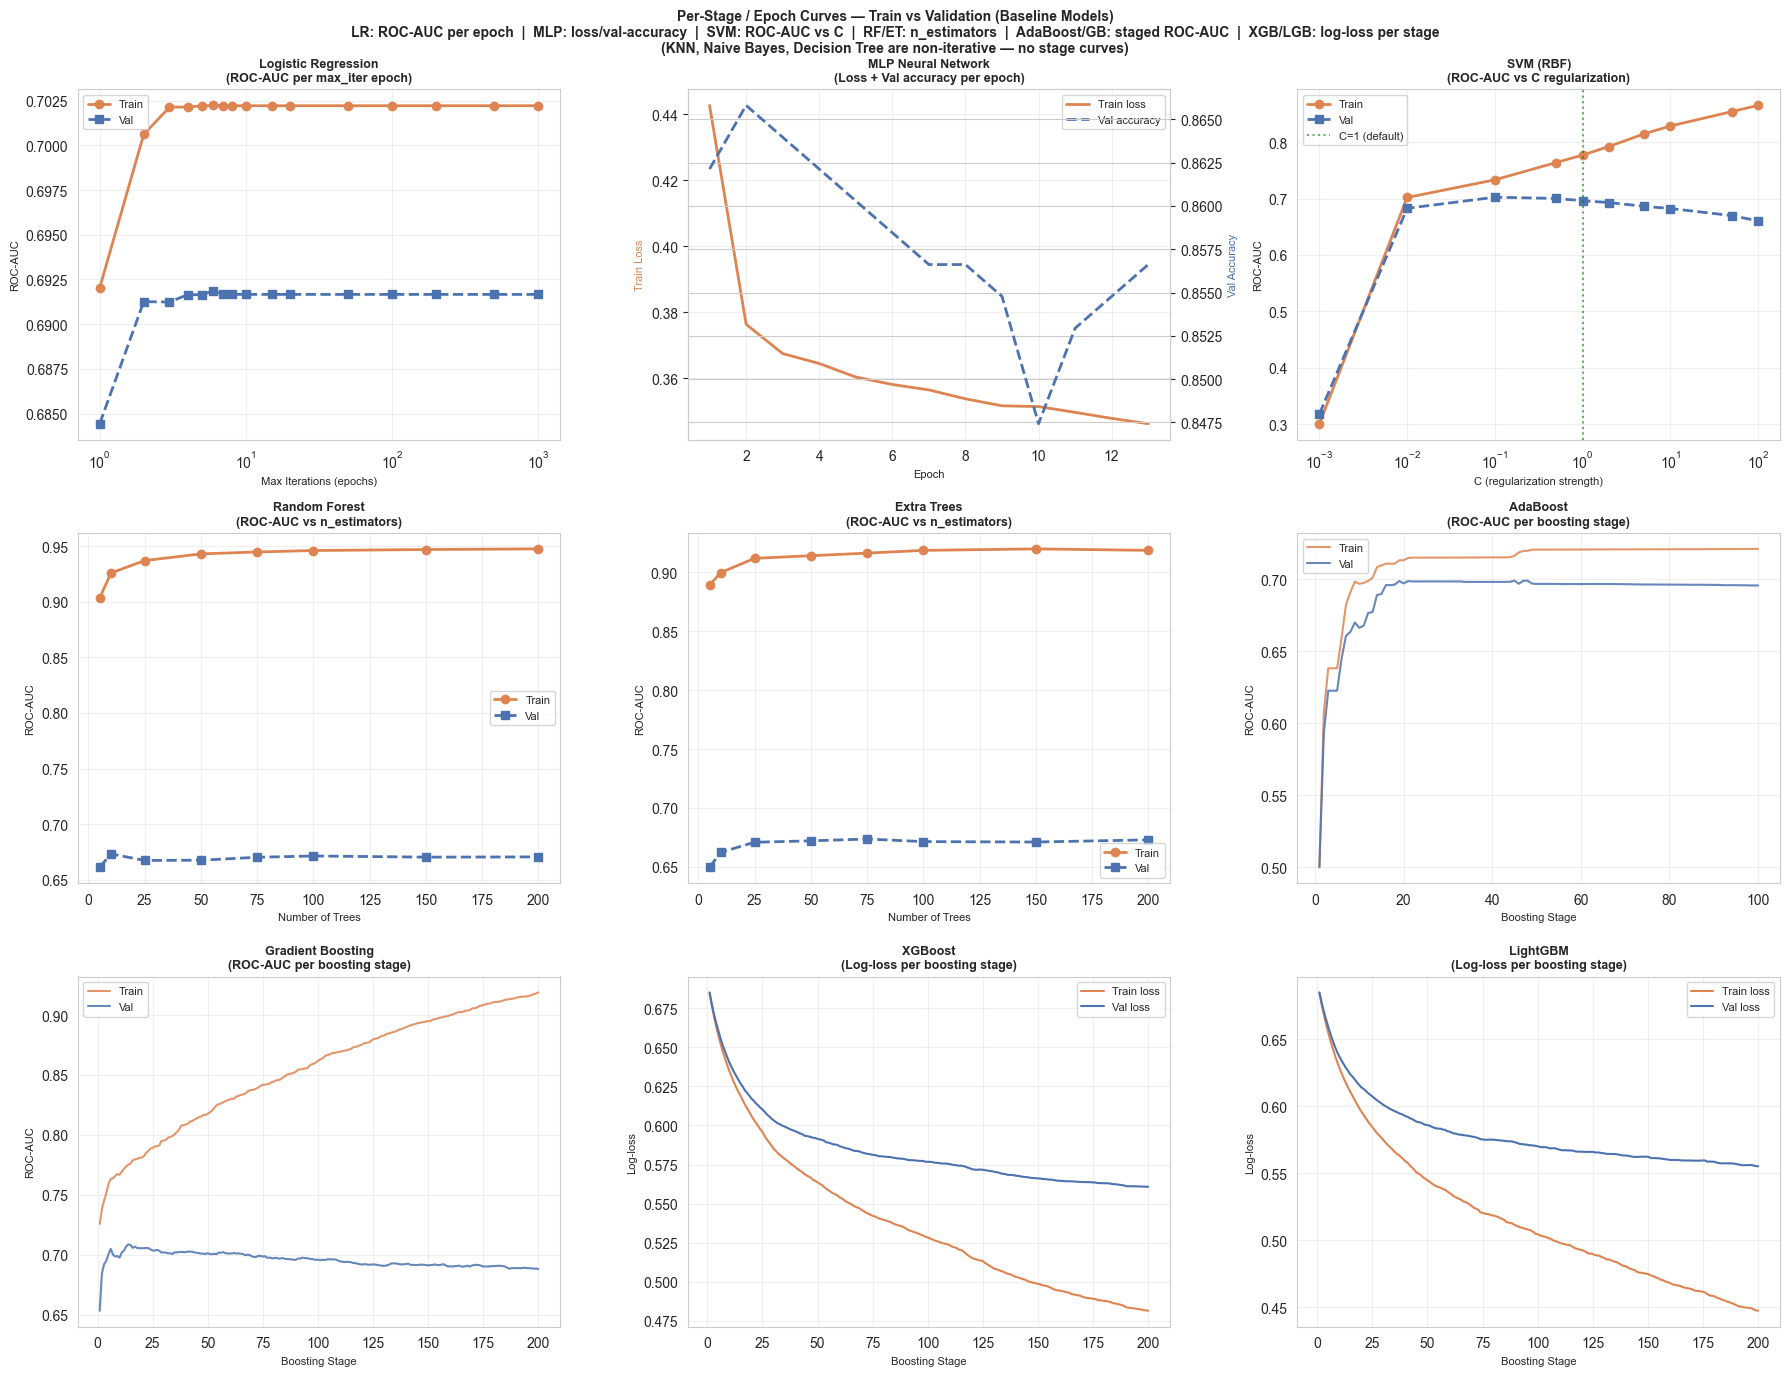


Saved: stage_epoch_curves_baseline.png


In [43]:

import lightgbm as lgb_lib

# ── Helper: extract preprocessed (imputed) train/test arrays ──────────────
def get_preprocessed_baseline(model_name):
    """Return (X_train_prep, X_test_prep) using the fitted pipeline's imputer."""
    pipe = trained_pipelines[model_name]
    prep = pipe.named_steps['preprocessor']
    return prep.transform(X_train), prep.transform(X_test)


fig, axes = plt.subplots(3, 3, figsize=(18, 14))

# ═══════════════ ROW 1 — Iterative models ═════════════════════════════════

# ── 1. Logistic Regression: ROC-AUC per max_iter epoch ────────────────────
print('LR epoch curve...', flush=True)
X_tr_p, X_te_p = get_preprocessed_baseline('Logistic Regression')
lr_iters = [1, 2, 3, 4, 5, 6, 7, 8, 10, 15, 20, 50, 100, 200, 500, 1000]
lr_train_c, lr_val_c = [], []
for mi in lr_iters:
    lr_tmp = LogisticRegression(max_iter=mi, random_state=RANDOM_STATE,
                                 class_weight='balanced', solver='lbfgs')
    try:
        lr_tmp.fit(X_tr_p, y_train)
    except Exception:
        pass
    lr_train_c.append(roc_auc_score(y_train, lr_tmp.predict_proba(X_tr_p)[:, 1]))
    lr_val_c.append(  roc_auc_score(y_test,  lr_tmp.predict_proba(X_te_p)[:, 1]))

ax = axes[0, 0]
ax.plot(lr_iters, lr_train_c, 'o-', color='#DD8452', linewidth=2, label='Train')
ax.plot(lr_iters, lr_val_c,   's--',color='#4C72B0', linewidth=2, label='Val')
ax.set_title('Logistic Regression\n(ROC-AUC per max_iter epoch)', fontweight='bold', fontsize=9)
ax.set_xlabel('Max Iterations (epochs)', fontsize=8)
ax.set_ylabel('ROC-AUC', fontsize=8)
ax.set_xscale('log')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── 2. MLP Neural Network: loss_curve_ + validation_scores_ ───────────────
print('MLP epoch curve...', flush=True)
mlp_clf  = trained_pipelines['MLP Neural Network'].named_steps['classifier']
n_ep_mlp = len(mlp_clf.loss_curve_)
epochs_mlp = np.arange(1, n_ep_mlp + 1)

ax  = axes[0, 1]
ax2 = ax.twinx()
ax.plot( epochs_mlp, mlp_clf.loss_curve_,         color='#DD8452', linewidth=2, label='Train loss')
ax2.plot(epochs_mlp, mlp_clf.validation_scores_,  color='#4C72B0', linewidth=2,
         linestyle='--', label='Val accuracy')
ax.set_title('MLP Neural Network\n(Loss + Val accuracy per epoch)',
             fontweight='bold', fontsize=9)
ax.set_xlabel('Epoch', fontsize=8)
ax.set_ylabel('Train Loss', fontsize=8, color='#DD8452')
ax2.set_ylabel('Val Accuracy', fontsize=8, color='#4C72B0')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)
ax.grid(alpha=0.3)

# ── 3. SVM (RBF): ROC-AUC vs C regularization strength ───────────────────
print('SVM C-sweep curve...', flush=True)
X_tr_p, X_te_p = get_preprocessed_baseline('SVM (RBF)')
c_values  = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 50.0, 100.0]
svm_train_c, svm_val_c = [], []
for c in c_values:
    svm_tmp = SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE,
                  class_weight='balanced', C=c, gamma='scale')
    svm_tmp.fit(X_tr_p, y_train)
    svm_train_c.append(roc_auc_score(y_train, svm_tmp.predict_proba(X_tr_p)[:, 1]))
    svm_val_c.append(  roc_auc_score(y_test,  svm_tmp.predict_proba(X_te_p)[:, 1]))

ax = axes[0, 2]
ax.plot(c_values, svm_train_c, 'o-', color='#DD8452', linewidth=2, label='Train')
ax.plot(c_values, svm_val_c,   's--',color='#4C72B0', linewidth=2, label='Val')
ax.axvline(1.0, color='green', linestyle=':', alpha=0.6, linewidth=1.5, label='C=1 (default)')
ax.set_title('SVM (RBF)\n(ROC-AUC vs C regularization)', fontweight='bold', fontsize=9)
ax.set_xlabel('C (regularization strength)', fontsize=8)
ax.set_ylabel('ROC-AUC', fontsize=8)
ax.set_xscale('log')
ax.legend(fontsize=8); ax.grid(alpha=0.3)


# ═══════════════ ROW 2 — Ensemble tree models ══════════════════════════════

rf_et_counts = [5, 10, 25, 50, 75, 100, 150, 200]

# ── 4. Random Forest: ROC-AUC vs n_estimators ─────────────────────────────
print('Random Forest tree-count curve...', flush=True)
X_tr_p, X_te_p = get_preprocessed_baseline('Random Forest')
rf_train_c, rf_val_c = [], []
for n in rf_et_counts:
    rf_tmp = RandomForestClassifier(n_estimators=n, max_depth=12, random_state=RANDOM_STATE,
                                     class_weight='balanced', n_jobs=-1)
    rf_tmp.fit(X_tr_p, y_train)
    rf_train_c.append(roc_auc_score(y_train, rf_tmp.predict_proba(X_tr_p)[:, 1]))
    rf_val_c.append(  roc_auc_score(y_test,  rf_tmp.predict_proba(X_te_p)[:, 1]))

ax = axes[1, 0]
ax.plot(rf_et_counts, rf_train_c, 'o-', color='#DD8452', linewidth=2, label='Train')
ax.plot(rf_et_counts, rf_val_c,   's--',color='#4C72B0', linewidth=2, label='Val')
ax.set_title('Random Forest\n(ROC-AUC vs n_estimators)', fontweight='bold', fontsize=9)
ax.set_xlabel('Number of Trees', fontsize=8)
ax.set_ylabel('ROC-AUC', fontsize=8)
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── 5. Extra Trees: ROC-AUC vs n_estimators ───────────────────────────────
print('Extra Trees tree-count curve...', flush=True)
X_tr_p, X_te_p = get_preprocessed_baseline('Extra Trees')
et_train_c, et_val_c = [], []
for n in rf_et_counts:
    et_tmp = ExtraTreesClassifier(n_estimators=n, max_depth=12, random_state=RANDOM_STATE,
                                   class_weight='balanced', n_jobs=-1)
    et_tmp.fit(X_tr_p, y_train)
    et_train_c.append(roc_auc_score(y_train, et_tmp.predict_proba(X_tr_p)[:, 1]))
    et_val_c.append(  roc_auc_score(y_test,  et_tmp.predict_proba(X_te_p)[:, 1]))

ax = axes[1, 1]
ax.plot(rf_et_counts, et_train_c, 'o-', color='#DD8452', linewidth=2, label='Train')
ax.plot(rf_et_counts, et_val_c,   's--',color='#4C72B0', linewidth=2, label='Val')
ax.set_title('Extra Trees\n(ROC-AUC vs n_estimators)', fontweight='bold', fontsize=9)
ax.set_xlabel('Number of Trees', fontsize=8)
ax.set_ylabel('ROC-AUC', fontsize=8)
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── 6. AdaBoost: staged_predict_proba → ROC-AUC per stage ─────────────────
print('AdaBoost staged curve...', flush=True)
X_tr_p, X_te_p = get_preprocessed_baseline('AdaBoost')
ada_clf = trained_pipelines['AdaBoost'].named_steps['classifier']
ada_train_c, ada_val_c = [], []
for proba in ada_clf.staged_predict_proba(X_tr_p):
    ada_train_c.append(roc_auc_score(y_train, proba[:, 1]))
for proba in ada_clf.staged_predict_proba(X_te_p):
    ada_val_c.append(roc_auc_score(y_test, proba[:, 1]))
stages_ada = np.arange(1, len(ada_train_c) + 1)

ax = axes[1, 2]
ax.plot(stages_ada, ada_train_c, color='#DD8452', linewidth=1.5, label='Train', alpha=0.85)
ax.plot(stages_ada, ada_val_c,   color='#4C72B0', linewidth=1.5, label='Val',   alpha=0.85)
ax.set_title('AdaBoost\n(ROC-AUC per boosting stage)', fontweight='bold', fontsize=9)
ax.set_xlabel('Boosting Stage', fontsize=8)
ax.set_ylabel('ROC-AUC', fontsize=8)
ax.legend(fontsize=8); ax.grid(alpha=0.3)


# ═══════════════ ROW 3 — Gradient boosting models ═════════════════════════

# ── 7. Gradient Boosting: staged_predict_proba ────────────────────────────
print('GB staged curve...', flush=True)
X_tr_p, X_te_p = get_preprocessed_baseline('Gradient Boosting')
clf_gb_b = trained_pipelines['Gradient Boosting'].named_steps['classifier']
gb_train_c, gb_val_c = [], []
for proba in clf_gb_b.staged_predict_proba(X_tr_p):
    gb_train_c.append(roc_auc_score(y_train, proba[:, 1]))
for proba in clf_gb_b.staged_predict_proba(X_te_p):
    gb_val_c.append(roc_auc_score(y_test, proba[:, 1]))
stages_gb = np.arange(1, len(gb_train_c) + 1)

ax = axes[2, 0]
ax.plot(stages_gb, gb_train_c, color='#DD8452', linewidth=1.5, label='Train', alpha=0.85)
ax.plot(stages_gb, gb_val_c,   color='#4C72B0', linewidth=1.5, label='Val',   alpha=0.85)
ax.set_title('Gradient Boosting\n(ROC-AUC per boosting stage)', fontweight='bold', fontsize=9)
ax.set_xlabel('Boosting Stage', fontsize=8)
ax.set_ylabel('ROC-AUC', fontsize=8)
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── 8. XGBoost: eval_set → log-loss per stage ─────────────────────────────
print('XGBoost staged curve...', flush=True)
X_tr_p, X_te_p = get_preprocessed_baseline('XGBoost')
xgb_stage_b = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.05,
    random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1, verbosity=0,
    scale_pos_weight=(y_train == 0).sum() / y_train.sum()
)
xgb_stage_b.fit(X_tr_p, y_train,
                eval_set=[(X_tr_p, y_train), (X_te_p, y_test)],
                verbose=False)
xgb_res_b = xgb_stage_b.evals_result_
xgb_stages_b = np.arange(1, len(xgb_res_b['validation_0']['logloss']) + 1)

ax = axes[2, 1]
ax.plot(xgb_stages_b, xgb_res_b['validation_0']['logloss'], color='#DD8452', linewidth=1.5, label='Train loss')
ax.plot(xgb_stages_b, xgb_res_b['validation_1']['logloss'], color='#4C72B0', linewidth=1.5, label='Val loss')
ax.set_title('XGBoost\n(Log-loss per boosting stage)', fontweight='bold', fontsize=9)
ax.set_xlabel('Boosting Stage', fontsize=8)
ax.set_ylabel('Log-loss', fontsize=8)
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── 9. LightGBM: eval_set → log-loss per stage ────────────────────────────
print('LightGBM staged curve...', flush=True)
X_tr_p, X_te_p = get_preprocessed_baseline('LightGBM')
lgb_stage_b = LGBMClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.05,
    random_state=RANDOM_STATE, class_weight='balanced', n_jobs=-1, verbose=-1
)
lgb_stage_b.fit(X_tr_p, y_train,
                eval_set=[(X_tr_p, y_train), (X_te_p, y_test)],
                eval_metric='binary_logloss',
                callbacks=[lgb_lib.record_evaluation(lgb_evals_b := {})])
lgb_stages_b = np.arange(1, 201)

ax = axes[2, 2]
ax.plot(lgb_stages_b, list(lgb_evals_b['training']['binary_logloss']), color='#DD8452', linewidth=1.5, label='Train loss')
ax.plot(lgb_stages_b, list(lgb_evals_b['valid_1']['binary_logloss']),  color='#4C72B0', linewidth=1.5, label='Val loss')
ax.set_title('LightGBM\n(Log-loss per boosting stage)', fontweight='bold', fontsize=9)
ax.set_xlabel('Boosting Stage', fontsize=8)
ax.set_ylabel('Log-loss', fontsize=8)
ax.legend(fontsize=8); ax.grid(alpha=0.3)


plt.suptitle(
    'Per-Stage / Epoch Curves — Train vs Validation (Baseline Models)\n'
    'LR: ROC-AUC per epoch  |  MLP: loss/val-accuracy  |  SVM: ROC-AUC vs C  |  '
    'RF/ET: n_estimators  |  AdaBoost/GB: staged ROC-AUC  |  XGB/LGB: log-loss per stage\n'
    '(KNN, Naive Bayes, Decision Tree are non-iterative — no stage curves)',
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
plt.savefig('baseline_outputs/images/stage_epoch_curves_baseline.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved: stage_epoch_curves_baseline.png')



## 7. Results Visualisation

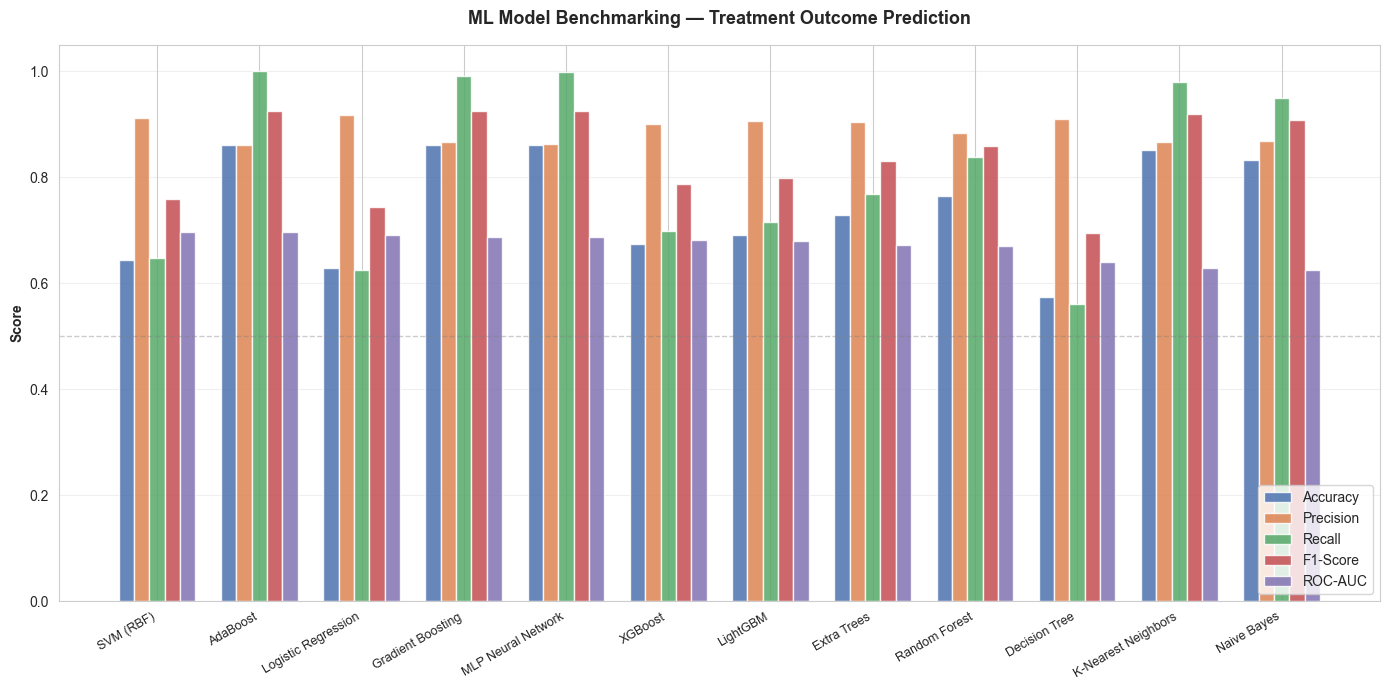

Saved: benchmark_comparison.png


In [28]:
# ── Benchmark comparison bar chart ────────────────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
plot_df = results_df.set_index('Model')[metrics]

fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(plot_df))
width = 0.15
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i * width, plot_df[metric].values, width, label=metric, color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x + width * 2)
ax.set_xticklabels(plot_df.index, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('ML Model Benchmarking — Treatment Outcome Prediction', fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.4, linewidth=1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_outputs/images/benchmark_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: benchmark_comparison.png')

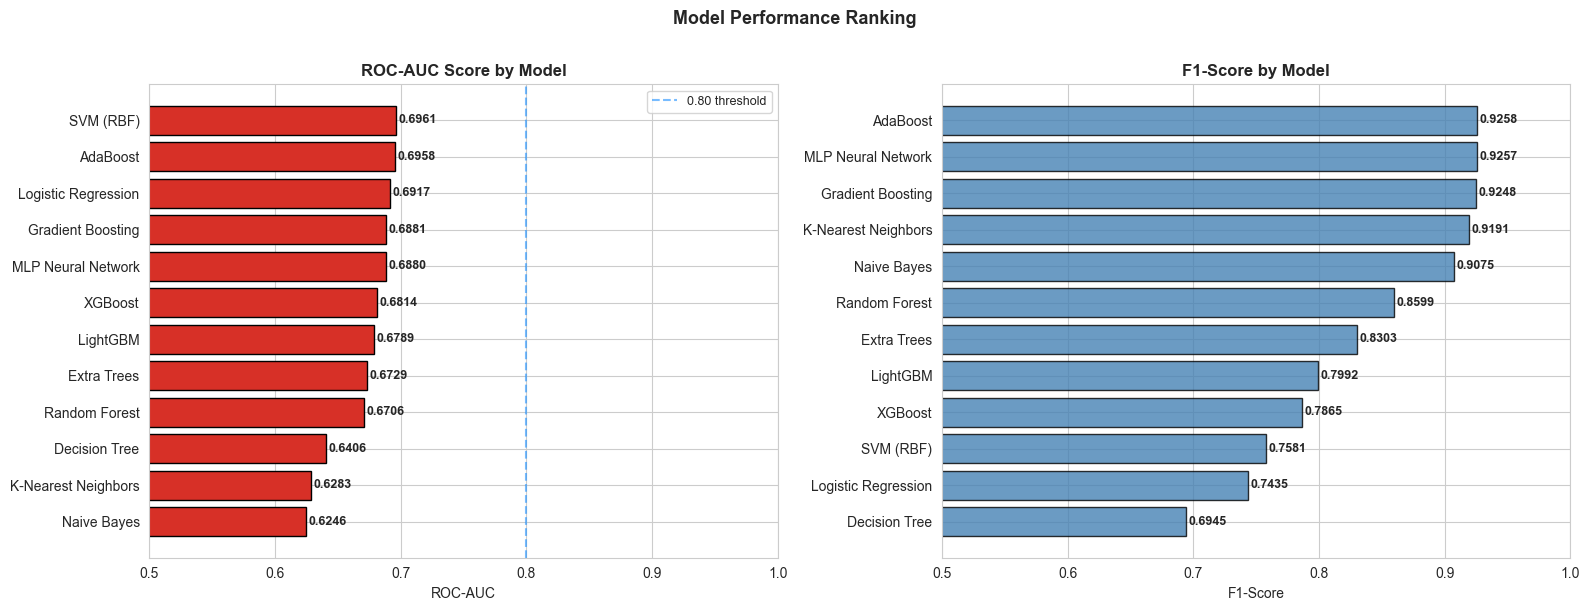

In [29]:
# ── ROC-AUC heatmap / ranking ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC-AUC by model
sorted_roc = results_df.sort_values('ROC-AUC', ascending=True)
colors_roc = ['#d73027' if v < 0.70 else '#fee08b' if v < 0.80 else '#1a9850'
               for v in sorted_roc['ROC-AUC']]
bars = axes[0].barh(sorted_roc['Model'], sorted_roc['ROC-AUC'], color=colors_roc, edgecolor='black')
for bar, val in zip(bars, sorted_roc['ROC-AUC']):
    axes[0].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
axes[0].set_xlim(0.5, 1.0)
axes[0].axvline(0.8, color='dodgerblue', linestyle='--', alpha=0.6, label='0.80 threshold')
axes[0].legend(fontsize=9)
axes[0].set_title('ROC-AUC Score by Model', fontweight='bold')
axes[0].set_xlabel('ROC-AUC')

# F1-Score by model
sorted_f1 = results_df.sort_values('F1-Score', ascending=True)
bars2 = axes[1].barh(sorted_f1['Model'], sorted_f1['F1-Score'], color='steelblue', edgecolor='black', alpha=0.8)
for bar, val in zip(bars2, sorted_f1['F1-Score']):
    axes[1].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
axes[1].set_xlim(0.5, 1.0)
axes[1].set_title('F1-Score by Model', fontweight='bold')
axes[1].set_xlabel('F1-Score')

plt.suptitle('Model Performance Ranking', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('baseline_outputs/images/model_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

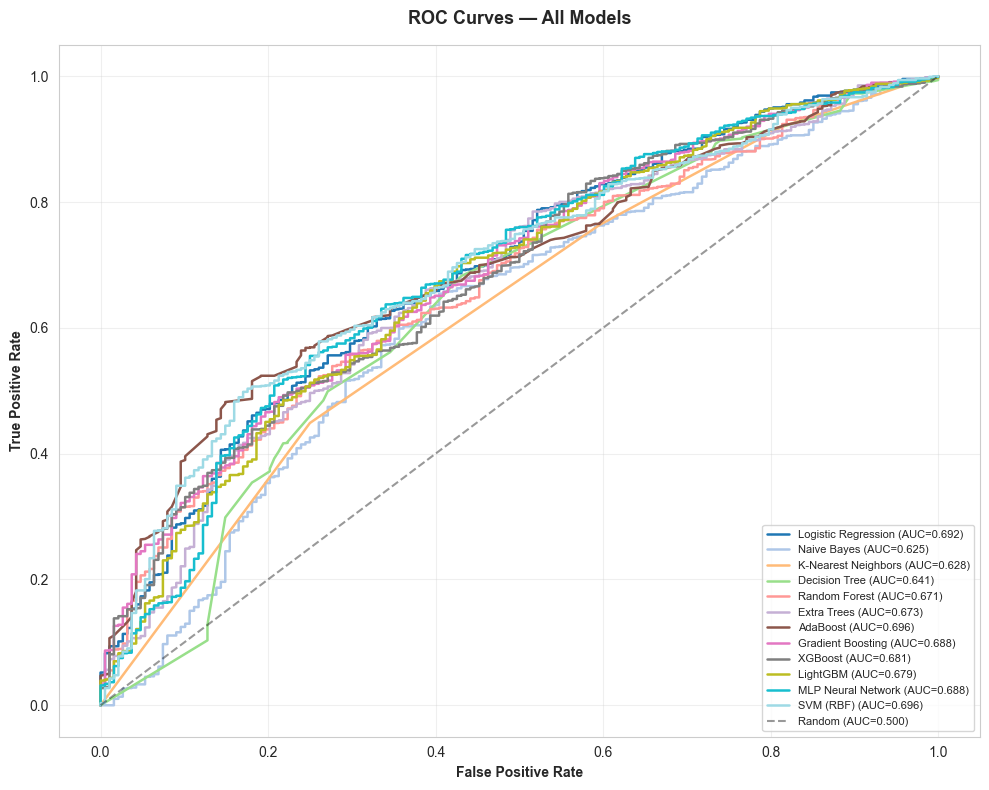

Saved: roc_curves_all_models.png


In [30]:
# ── ROC Curves for all models ──────────────────────────────────────────────
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(10, 8))

cmap = plt.cm.get_cmap('tab20', len(MODELS))

for i, (name, pipe) in enumerate(trained_pipelines.items()):
    y_proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=cmap(i), linewidth=1.8)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate', fontweight='bold')
ax.set_ylabel('True Positive Rate', fontweight='bold')
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_outputs/images/roc_curves_all_models.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: roc_curves_all_models.png')

## 8. Best Model — Detailed Analysis

In [31]:
# ── Identify best model by ROC-AUC ────────────────────────────────────────
best_model_name = results_df.iloc[0]['Model']
best_pipe = trained_pipelines[best_model_name]
print(f'Best model: {best_model_name}')
print(f"  ROC-AUC : {results_df.iloc[0]['ROC-AUC']:.4f}")
print(f"  F1-Score: {results_df.iloc[0]['F1-Score']:.4f}")

y_pred_best  = best_pipe.predict(X_test)
y_proba_best = best_pipe.predict_proba(X_test)[:, 1]

print('\nClassification Report:')
print(classification_report(y_test, y_pred_best, target_names=['Failure', 'Success']))

Best model: SVM (RBF)
  ROC-AUC : 0.6961
  F1-Score: 0.7581

Classification Report:
              precision    recall  f1-score   support

     Failure       0.22      0.61      0.32       188
     Success       0.91      0.65      0.76      1172

    accuracy                           0.64      1360
   macro avg       0.57      0.63      0.54      1360
weighted avg       0.82      0.64      0.70      1360



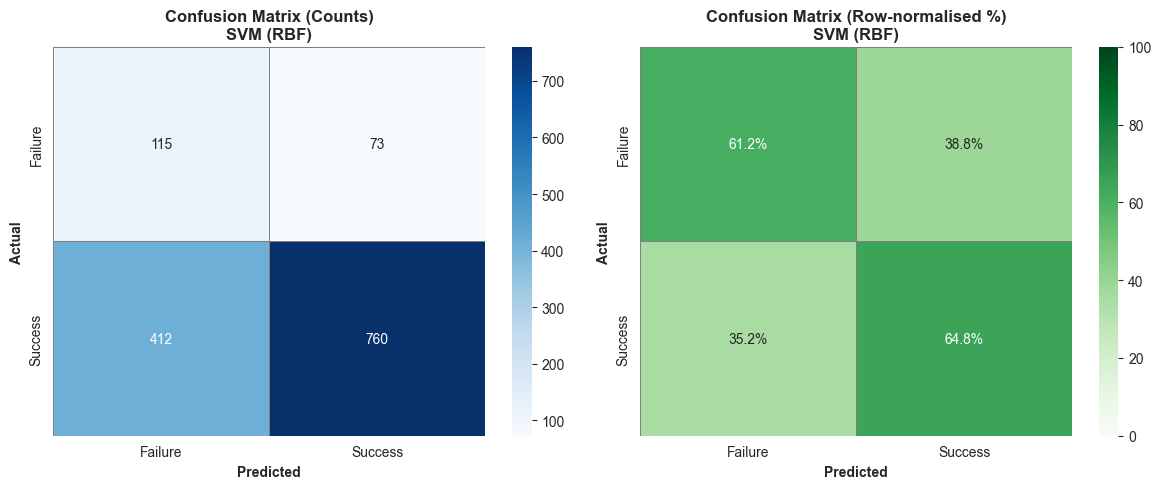

In [32]:
# ── Confusion matrix for best model ───────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_best)
cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Failure', 'Success'],
            yticklabels=['Failure', 'Success'],
            linewidths=0.5, linecolor='gray')
axes[0].set_xlabel('Predicted', fontweight='bold')
axes[0].set_ylabel('Actual', fontweight='bold')
axes[0].set_title(f'Confusion Matrix (Counts)\n{best_model_name}', fontweight='bold')

# Percentages per row (normalised)
labels = [[f'{v:.1f}%' for v in row] for row in cm_pct]
sns.heatmap(cm_pct, annot=labels, fmt='', cmap='Greens', ax=axes[1],
            xticklabels=['Failure', 'Success'],
            yticklabels=['Failure', 'Success'],
            linewidths=0.5, linecolor='gray', vmin=0, vmax=100)
axes[1].set_xlabel('Predicted', fontweight='bold')
axes[1].set_ylabel('Actual', fontweight='bold')
axes[1].set_title(f'Confusion Matrix (Row-normalised %)\n{best_model_name}', fontweight='bold')

plt.tight_layout()
plt.savefig('baseline_outputs/images/confusion_matrix_best.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Feature Importance

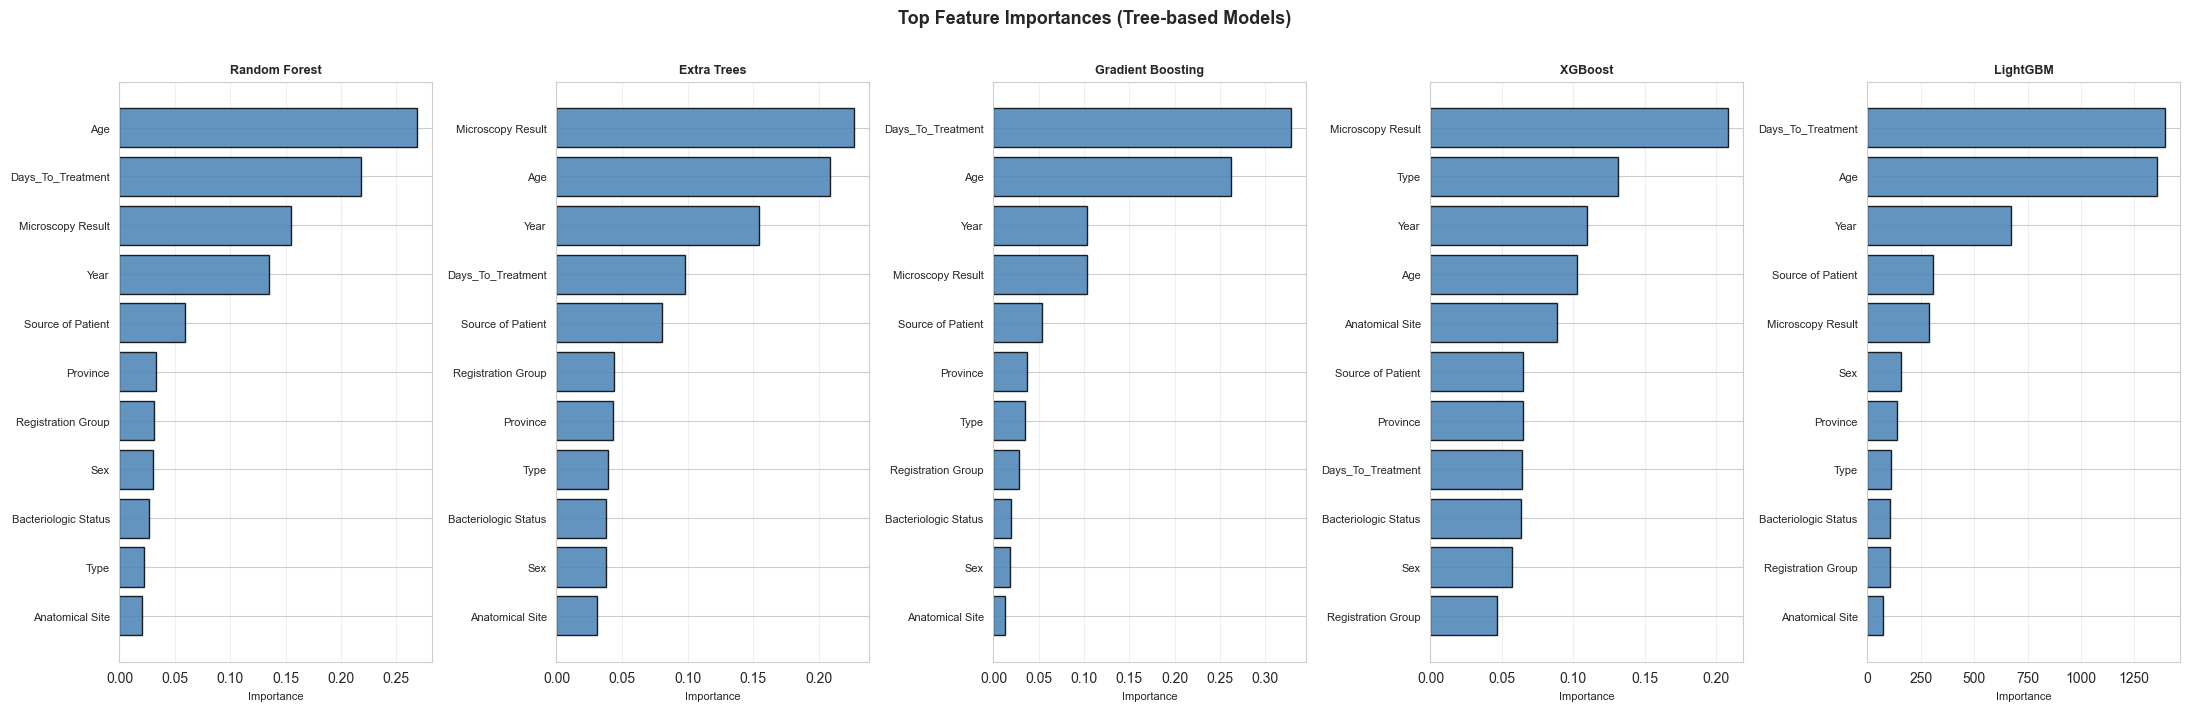

Saved: feature_importance_tree_models.png


In [33]:
# ── Feature importance from tree-based models ─────────────────────────────
def get_feature_names(pipe):
    """Extract feature names after preprocessing (ml-ready: no encoding step)."""
    return ALL_FEATURES

TREE_MODELS = ['Random Forest', 'Extra Trees', 'Gradient Boosting', 'XGBoost', 'LightGBM']

fig, axes = plt.subplots(1, len(TREE_MODELS), figsize=(22, 7))

for ax, model_name in zip(axes, TREE_MODELS):
    pipe    = trained_pipelines[model_name]
    clf     = pipe.named_steps['classifier']
    feat_names = get_feature_names(pipe)
    importances = clf.feature_importances_

    # Top 12 features (or all if fewer)
    top_n = min(12, len(feat_names))
    top_idx   = np.argsort(importances)[-top_n:]
    top_names = [feat_names[i] for i in top_idx]
    top_vals  = importances[top_idx]

    ax.barh(range(top_n), top_vals, color='steelblue', edgecolor='black', alpha=0.85)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_names, fontsize=8)
    ax.set_title(model_name, fontweight='bold', fontsize=9)
    ax.set_xlabel('Importance', fontsize=8)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Top Feature Importances (Tree-based Models)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('baseline_outputs/images/feature_importance_tree_models.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_importance_tree_models.png')

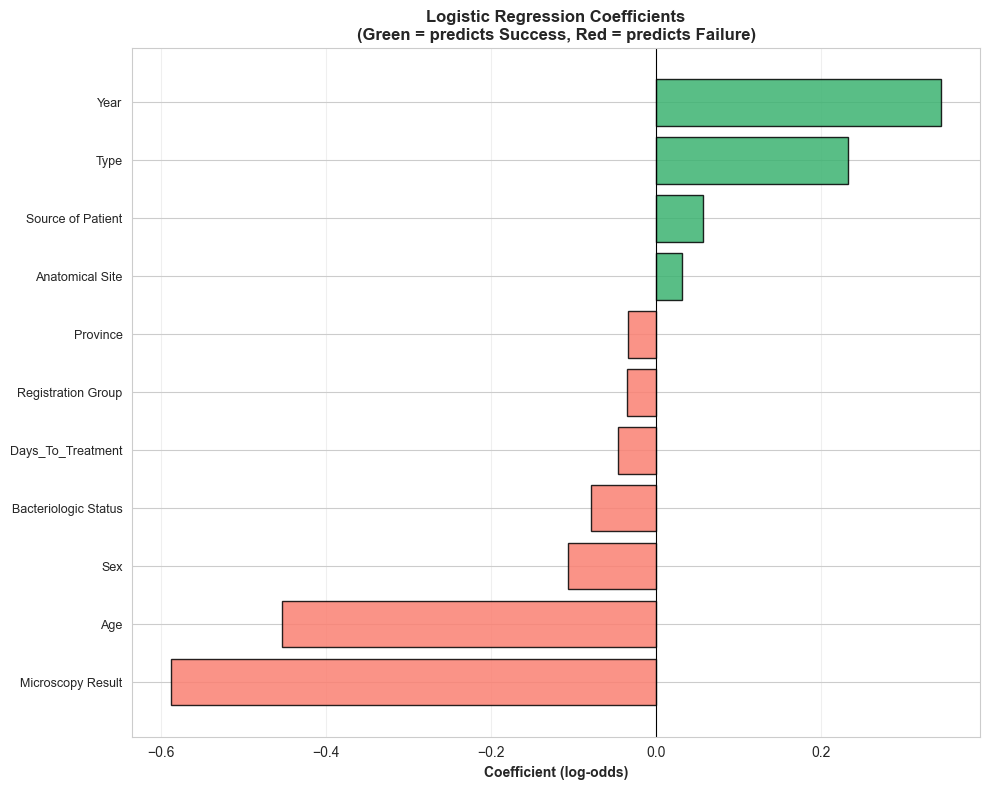

In [34]:
# ── Logistic Regression coefficients ──────────────────────────────────────
lr_pipe  = trained_pipelines['Logistic Regression']
lr_clf   = lr_pipe.named_steps['classifier']
feat_names = get_feature_names(lr_pipe)
coefs    = lr_clf.coef_[0]

# Show all features (no OneHot expansion, so feature count is manageable)
sorted_idx = np.argsort(coefs)
x_vals  = coefs[sorted_idx]
x_names = [feat_names[i] for i in sorted_idx]

colors_lr = ['salmon' if v < 0 else 'mediumseagreen' for v in x_vals]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(x_vals)), x_vals, color=colors_lr, edgecolor='black', alpha=0.85)
ax.set_yticks(range(len(x_vals)))
ax.set_yticklabels(x_names, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (log-odds)', fontweight='bold')
ax.set_title('Logistic Regression Coefficients\n(Green = predicts Success, Red = predicts Failure)',
             fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_outputs/images/logreg_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Cross-Validation

In [35]:
# ── 5-fold stratified cross-validation on full dataset ────────────────────
CV_MODELS = {
    'Logistic Regression': MODELS['Logistic Regression'],
    'Random Forest':       MODELS['Random Forest'],
    'Gradient Boosting':   MODELS['Gradient Boosting'],
    'XGBoost':             MODELS['XGBoost'],
    'LightGBM':            MODELS['LightGBM'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = []

for name, model in CV_MODELS.items():
    print(f'Cross-validating {name}...', end=' ', flush=True)
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    scores = cross_validate(
        pipe, X, y, cv=cv,
        scoring=['accuracy', 'f1', 'roc_auc', 'recall', 'precision'],
        n_jobs=-1
    )
    cv_results.append({
        'Model':         name,
        'CV Accuracy':   f"{scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}",
        'CV F1':         f"{scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}",
        'CV ROC-AUC':    f"{scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}",
        'CV Recall':     f"{scores['test_recall'].mean():.4f} ± {scores['test_recall'].std():.4f}",
        'CV Precision':  f"{scores['test_precision'].mean():.4f} ± {scores['test_precision'].std():.4f}",
    })
    print('done')

cv_df = pd.DataFrame(cv_results)
print('\n5-Fold Stratified Cross-Validation Results:')
print(cv_df.to_string(index=False))

Cross-validating Logistic Regression... done
Cross-validating Random Forest... done
Cross-validating Gradient Boosting... done
Cross-validating XGBoost... done
Cross-validating LightGBM... done

5-Fold Stratified Cross-Validation Results:
              Model     CV Accuracy           CV F1      CV ROC-AUC       CV Recall    CV Precision
Logistic Regression 0.6390 ± 0.0038 0.7527 ± 0.0045 0.6942 ± 0.0040 0.6378 ± 0.0089 0.9185 ± 0.0058
      Random Forest 0.7764 ± 0.0080 0.8674 ± 0.0053 0.6886 ± 0.0133 0.8488 ± 0.0100 0.8869 ± 0.0036
  Gradient Boosting 0.8576 ± 0.0037 0.9226 ± 0.0020 0.6919 ± 0.0146 0.9851 ± 0.0037 0.8676 ± 0.0024
            XGBoost 0.6709 ± 0.0151 0.7836 ± 0.0121 0.6824 ± 0.0103 0.6920 ± 0.0175 0.9035 ± 0.0029
           LightGBM 0.6821 ± 0.0102 0.7932 ± 0.0084 0.6854 ± 0.0113 0.7076 ± 0.0136 0.9025 ± 0.0015


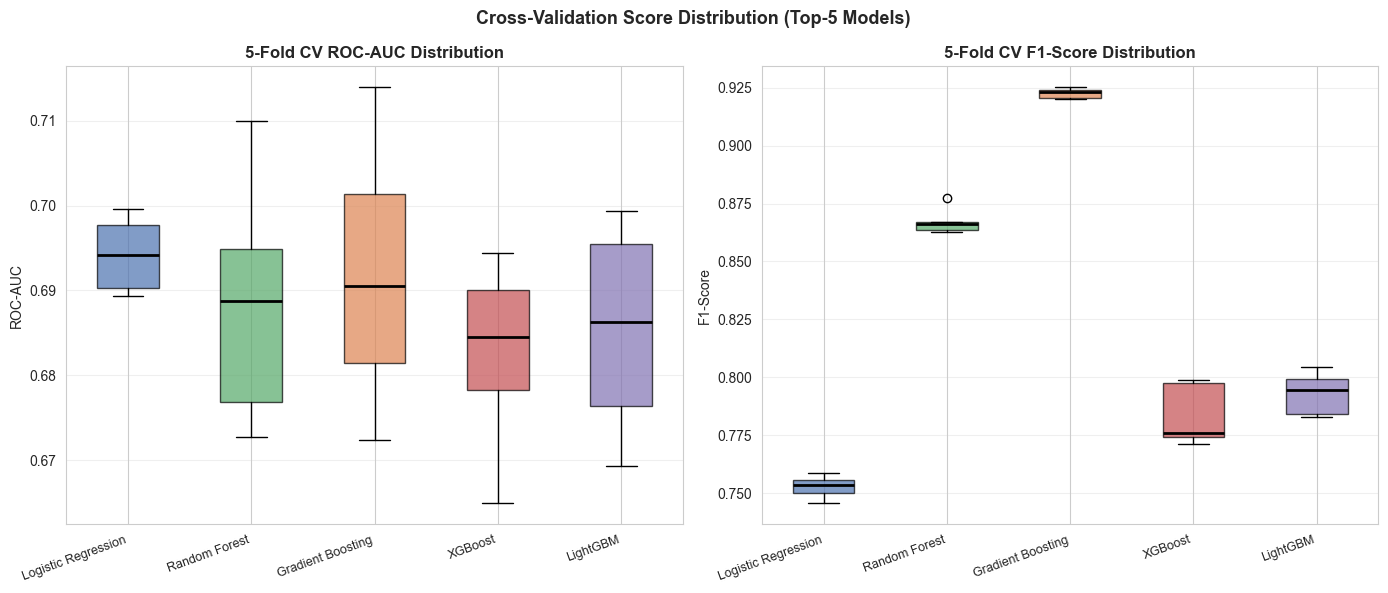

In [36]:
# ── CV ROC-AUC boxplot ─────────────────────────────────────────────────────
cv_box_data = {}
for name, model in CV_MODELS.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    scores = cross_validate(pipe, X, y, cv=cv, scoring=['roc_auc', 'f1'], n_jobs=-1)
    cv_box_data[name] = {
        'roc_auc': scores['test_roc_auc'],
        'f1':      scores['test_f1'],
    }

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, metric, title in zip(axes, ['roc_auc', 'f1'], ['ROC-AUC', 'F1-Score']):
    box_vals = [cv_box_data[n][metric] for n in CV_MODELS]
    bp = ax.boxplot(box_vals, labels=list(CV_MODELS.keys()), patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    colors_box = ['#4C72B0', '#55A868', '#DD8452', '#C44E52', '#8172B2']
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels(list(CV_MODELS.keys()), rotation=20, ha='right', fontsize=9)
    ax.set_title(f'5-Fold CV {title} Distribution', fontweight='bold')
    ax.set_ylabel(title)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Cross-Validation Score Distribution (Top-5 Models)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_outputs/images/cv_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Confusion Matrices — All Models

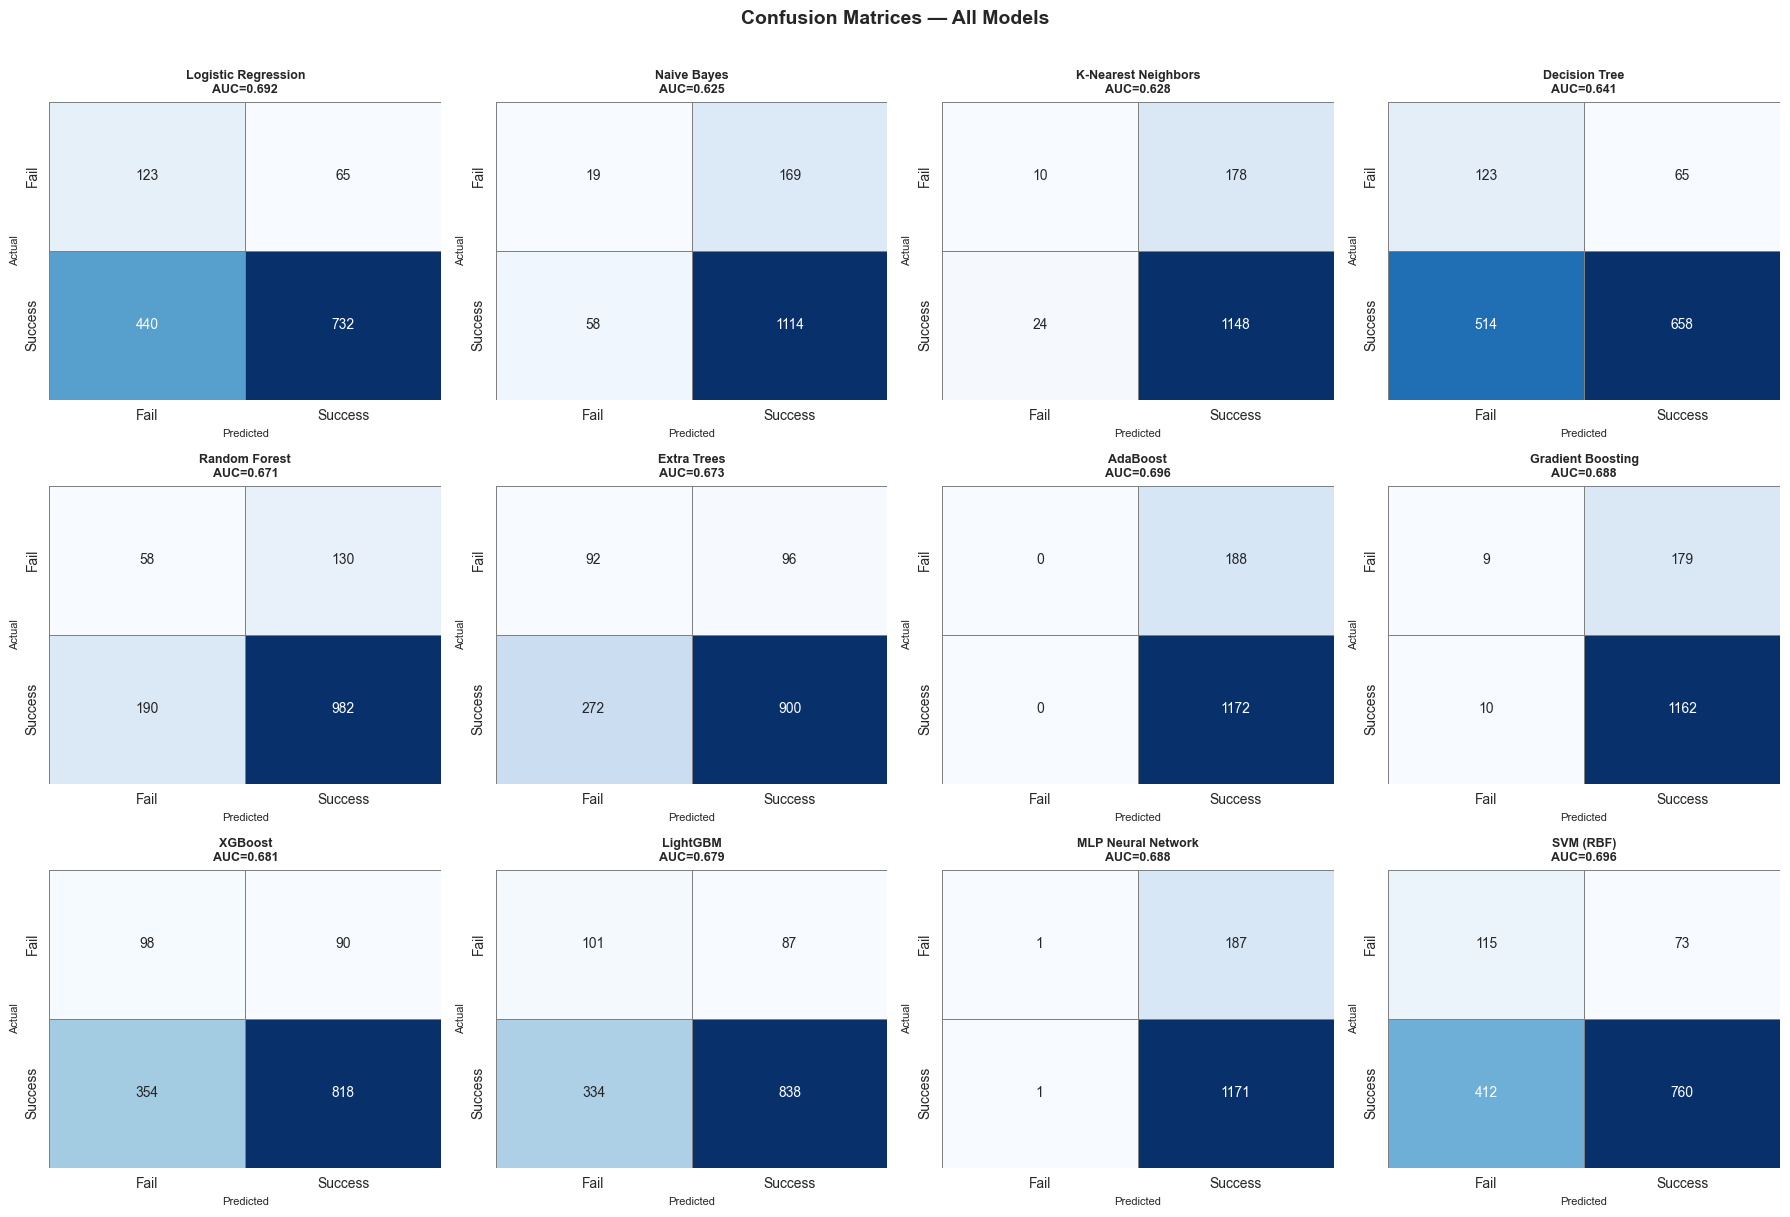

Saved: confusion_matrices_all.png


In [37]:
# ── 4×3 grid of confusion matrices for all 12 models ──────────────────────
model_names = list(MODELS.keys())
n_models    = len(model_names)
n_cols      = 4
n_rows      = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, name in enumerate(model_names):
    pipe   = trained_pipelines[name]
    y_pred = pipe.predict(X_test)
    cm_    = confusion_matrix(y_test, y_pred)
    auc    = roc_auc_score(y_test, pipe.predict_proba(X_test)[:, 1])

    sns.heatmap(cm_, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Fail', 'Success'], yticklabels=['Fail', 'Success'],
                linewidths=0.5, linecolor='gray', cbar=False)
    axes[i].set_title(f'{name}\nAUC={auc:.3f}', fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Predicted', fontsize=8)
    axes[i].set_ylabel('Actual', fontsize=8)

# Hide unused axes
for j in range(n_models, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('baseline_outputs/images/confusion_matrices_all.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrices_all.png')

## 12. Save Best Model and Results

In [38]:
# ── Save best model pipeline ───────────────────────────────────────────────
joblib.dump(trained_pipelines[best_model_name], f'baseline_outputs/models/best_model_{best_model_name.replace(" ", "_")}.pkl')
print(f'Saved best model: baseline_outputs/models/best_model_{best_model_name.replace(" ", "_")}.pkl')

# Save all results to CSV
results_df.to_csv('baseline_outputs/ml_benchmark_results.csv', index=False)
print('Saved benchmark results: baseline_outputs/ml_benchmark_results.csv')

# Save cross-validation results
cv_df.to_csv('baseline_outputs/cv_results.csv', index=False)
print('Saved CV results: baseline_outputs/cv_results.csv')

Saved best model: baseline_outputs/models/best_model_SVM_(RBF).pkl
Saved benchmark results: baseline_outputs/ml_benchmark_results.csv
Saved CV results: baseline_outputs/cv_results.csv


## 13. Summary

In [39]:
# ── Final summary dashboard ────────────────────────────────────────────────
print('=' * 70)
print('  TB TREATMENT OUTCOME PREDICTION — BASELINE BENCHMARK SUMMARY')
print('=' * 70)
print(f'  Dataset : 2015-2025-ml-ready.csv (pre-encoded & scaled)')
print(f'  Records : {len(df):,} (Success: {y.sum():,} | Failure: {(y==0).sum():,})')
print(f'  Features: {len(ALL_FEATURES)} (all pre-encoded & standard-scaled)')
print(f'  Split   : 80% train / 20% test (stratified)')
print()
print(f'  Top 5 Models by ROC-AUC:')
for _, row in results_df.head(5).iterrows():
    marker = ' ◄ BEST' if row['Model'] == best_model_name else ''
    print(f"    {row.name}. {row['Model']:<28} AUC={row['ROC-AUC']:.4f}  F1={row['F1-Score']:.4f}{marker}")
print()
print(f'  Best Model  : {best_model_name}')
best_row = results_df[results_df['Model'] == best_model_name].iloc[0]
print(f'  Accuracy    : {best_row["Accuracy"]:.4f}')
print(f'  Precision   : {best_row["Precision"]:.4f}')
print(f'  Recall      : {best_row["Recall"]:.4f}')
print(f'  F1-Score    : {best_row["F1-Score"]:.4f}')
print(f'  ROC-AUC     : {best_row["ROC-AUC"]:.4f}')
print('=' * 70)
print()
print('  Outputs saved to baseline_outputs/')
print('    • ml_benchmark_results.csv')
print('    • cv_results.csv')
print('    • models/best_model_*.pkl')
print('    • images/*.png')
print('=' * 70)

  TB TREATMENT OUTCOME PREDICTION — BASELINE BENCHMARK SUMMARY
  Dataset : 2015-2025-ml-ready.csv (pre-encoded & scaled)
  Records : 6,797 (Success: 5,858 | Failure: 939)
  Features: 11 (all pre-encoded & standard-scaled)
  Split   : 80% train / 20% test (stratified)

  Top 5 Models by ROC-AUC:
    1. SVM (RBF)                    AUC=0.6961  F1=0.7581 ◄ BEST
    2. AdaBoost                     AUC=0.6958  F1=0.9258
    3. Logistic Regression          AUC=0.6917  F1=0.7435
    4. Gradient Boosting            AUC=0.6881  F1=0.9248
    5. MLP Neural Network           AUC=0.6880  F1=0.9257

  Best Model  : SVM (RBF)
  Accuracy    : 0.6434
  Precision   : 0.9124
  Recall      : 0.6485
  F1-Score    : 0.7581
  ROC-AUC     : 0.6961

  Outputs saved to baseline_outputs/
    • ml_benchmark_results.csv
    • cv_results.csv
    • models/best_model_*.pkl
    • images/*.png
